# Description

In this notebook, we prepare the illustration plots of parameter convergence for different operations. The operations include division, and sine.

# 1. Division

device: cpu | N: 100 | y_true min/max: -33.00009536743164 33.00009536743164

Real model:
  epochs: 289
  best MSE: 53.72098159790039
  final a: 1.5153974294662476

Complex model:
  epochs: 3298
  best MSE: 2.5247112489523715e-07
  final a: 0.000000 + -0.000706j


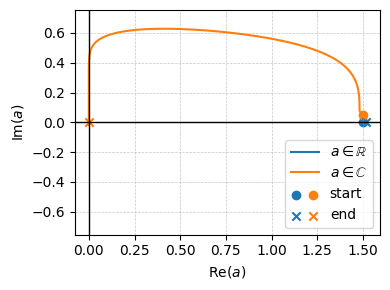

In [31]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# ---- setup + data (CPU only) ----
torch.manual_seed(0)

x = torch.linspace(-3.0, 3.0, 100)
x = x[x != 0.0]
y_true = 1.0 / x

clip_y = 100.0
mask = y_true.abs() <= clip_y
x, y_true = x[mask], y_true[mask]

print("device: cpu | N:", x.numel(), "| y_true min/max:", y_true.min().item(), y_true.max().item())

# ---- models ----
class RealShiftDivision(nn.Module):
    def __init__(self, a0=1.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(a0))

    def forward(self, x):
        return 1.0 / (x + self.a)

class ComplexShiftDivision(nn.Module):
    def __init__(self, a0=1.0, a_imag0=0.1):
        super().__init__()
        self.a = nn.Parameter(torch.complex(torch.tensor(a0), torch.tensor(a_imag0)))

    def forward(self, x, eps=1e-6):
        z = x.to(torch.complex64) + self.a
        z = torch.where(z.abs() < eps, eps + 0.0j * z, z)
        return (1.0 / z).real

# ---- training (Adam + stop on plateau) + trajectory logging ----
def fit_with_traj(model, x, y_true, lr=1e-3, max_epochs=20000, plateau_tol=1e-6, patience=200):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    best = float("inf")
    no_improve = 0

    traj_re, traj_im = [], []

    for epoch in range(1, max_epochs + 1):
        with torch.no_grad():
            a = model.a.detach()
            if torch.is_complex(a):
                traj_re.append(float(a.real))
                traj_im.append(float(a.imag))
            else:
                traj_re.append(float(a))
                traj_im.append(0.0)

        opt.zero_grad(set_to_none=True)
        loss = mse(model(x), y_true)
        loss.backward()
        opt.step()

        loss_val = loss.item()
        if loss_val < best - plateau_tol:
            best = loss_val
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    with torch.no_grad():
        a = model.a.detach()
        if torch.is_complex(a):
            traj_re.append(float(a.real))
            traj_im.append(float(a.imag))
        else:
            traj_re.append(float(a))
            traj_im.append(0.0)

    return epoch, best, traj_re, traj_im

# ---- run ----
a0 = 1.5
a_imag0 = 0.05

m_real = RealShiftDivision(a0)
m_cplx = ComplexShiftDivision(a0, a_imag0)

e_r, best_r, re_r, im_r = fit_with_traj(m_real, x, y_true)
e_c, best_c, re_c, im_c = fit_with_traj(m_cplx, x, y_true)

print("\nReal model:")
print("  epochs:", e_r)
print("  best MSE:", best_r)
print("  final a:", float(m_real.a.detach()))

print("\nComplex model:")
a = m_cplx.a.detach().numpy()
print("  epochs:", e_c)
print("  best MSE:", best_c)
print(f"  final a: {a.real:.6f} + {a.imag:.6f}j")

# ---- plot trajectories in (Re(a), Im(a)) ----
im_abs_max = max(1e-3, max(abs(v) for v in im_c))
im_lim = 1.2 * im_abs_max

plt.figure(figsize=(4.0, 3.0))

line_real, = plt.plot(re_r, im_r, label=r"$a\in\mathbb{R}$")
line_cplx, = plt.plot(re_c, im_c, label=r"$a\in\mathbb{C}$")

start_real = plt.scatter(re_r[0], im_r[0], marker="o", color=line_real.get_color())
start_cplx = plt.scatter(re_c[0], im_c[0], marker="o", color=line_cplx.get_color())
end_real   = plt.scatter(re_r[-1], im_r[-1], marker="x", color=line_real.get_color())
end_cplx   = plt.scatter(re_c[-1], im_c[-1], marker="x", color=line_cplx.get_color())

plt.axhline(0.0, linewidth=1.0, color="black")
plt.axvline(0.0, linewidth=1.0, color="black")

plt.xlabel(r"$\mathrm{Re}(a)$")
plt.ylabel(r"$\mathrm{Im}(a)$")
plt.ylim(-im_lim, im_lim)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# ---- legend: 4 entries total ----
start_tuple = (start_real, start_cplx)
end_tuple = (end_real, end_cplx)

handles = [line_real, line_cplx, start_tuple, end_tuple]
labels = [r"$a\in\mathbb{R}$", r"$a\in\mathbb{C}$", "start", "end"]

plt.legend(
    handles, labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="best"
)

plt.tight_layout()

# ---- save figure ----
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/division_convergence.pdf", bbox_inches='tight')

plt.show()


device: cpu | N: 994 | y_true min/max: -61.937374114990234 61.937374114990234
[STD | ep=   0] loss=5.187472e+01 best=5.187472e+01 amp=0.999000+0.999000j b=10.001000+1.001000j
[STD | ep= 500] loss=5.089989e+01 best=5.089989e+01 amp=0.609167+0.554643j b=10.347739+1.292359j
[STD | ep=1000] loss=5.052777e+01 best=5.052777e+01 amp=0.348509+0.229487j b=10.530604+1.348291j
[STD | ep=1500] loss=5.041484e+01 best=5.041484e+01 amp=0.185474+0.024494j b=10.648980+1.327182j
[STD | ep=2000] loss=5.039282e+01 best=5.039282e+01 amp=0.123768+-0.077263j b=10.768999+1.309639j
[STD | ep=2500] loss=5.038903e+01 best=5.038903e+01 amp=0.133640+-0.115311j b=10.940867+1.277292j
[STD | ep=3000] loss=5.038572e+01 best=5.038572e+01 amp=0.162987+-0.128684j b=11.114419+1.112693j
[STD | ep=3500] loss=4.906934e+01 best=4.906928e+01 amp=0.726457+-0.181109j b=10.995764+0.067473j
[STD | ep=4000] loss=4.906800e+01 best=4.906800e+01 amp=0.724217+-0.210831j b=10.999280+0.067121j
[STD | ep=4500] loss=4.906801e+01 best=4.906

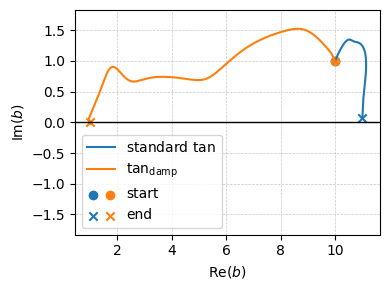

In [44]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# ---- setup + data (CPU only) ----
torch.manual_seed(0)

x = torch.linspace(-10.0, 10.0, 1000)

# Ground truth: tan(x), clip out points near poles (and any non-finite values)
y_true = torch.tan(x)
clip_y = 100.0
mask = torch.isfinite(y_true) & (y_true.abs() <= clip_y)
x, y_true = x[mask], y_true[mask]

print("device: cpu | N:", x.numel(), "| y_true min/max:", y_true.min().item(), y_true.max().item())

# ---- sanitization ----
CLAMP_VAL = 1e6

def _sanitize_out(z: torch.Tensor) -> torch.Tensor:
    if torch.is_complex(z):
        zr = torch.nan_to_num(z.real, nan=0.0, posinf=CLAMP_VAL, neginf=-CLAMP_VAL)
        zi = torch.nan_to_num(z.imag, nan=0.0, posinf=CLAMP_VAL, neginf=-CLAMP_VAL)
        zr = torch.clamp(zr, -CLAMP_VAL, CLAMP_VAL)
        zi = torch.clamp(zi, -CLAMP_VAL, CLAMP_VAL)
        return torch.complex(zr, zi)
    z = torch.nan_to_num(z, nan=0.0, posinf=CLAMP_VAL, neginf=-CLAMP_VAL)
    return torch.clamp(z, -CLAMP_VAL, CLAMP_VAL)

# ---- damped tan surrogate (your implementation) ----
def tan_operation_surrogate(x: torch.Tensor, *, r: float, **_) -> torch.Tensor:
    u = x.real
    v = x.imag
    r = float(max(min(r, 1.0), 1e-12))

    log_r = torch.log(torch.tensor(r, device=u.device, dtype=u.dtype))
    phi = u.abs()
    damp = torch.exp(log_r * phi)

    num_real = damp * torch.sin(u)
    num = torch.complex(num_real, torch.zeros_like(num_real))

    den_real = damp * torch.cos(u)
    den = torch.complex(den_real, v)

    y = _sanitize_out(num / den)
    return y.unsqueeze(-1)

# ---- models: y = amp * tan(freq * x) ----
class StandardComplexTan(nn.Module):
    # returns COMPLEX prediction; loss will use only .real
    def __init__(
        self,
        amp0_re=1.0, amp0_im=0.0,
        b0_re=0.1, b0_im=0.1,
    ):
        super().__init__()
        self.amp = nn.Parameter(torch.complex(torch.tensor(amp0_re), torch.tensor(amp0_im)))
        self.b   = nn.Parameter(torch.complex(torch.tensor(b0_re),   torch.tensor(b0_im)))

    def forward(self, x):
        z = x.to(torch.complex64) * self.b
        y = _sanitize_out(torch.tan(z))
        y = self.amp * y
        return _sanitize_out(y)  # complex (N,)

class DampedTanModel(nn.Module):
    # returns COMPLEX prediction; loss will use only .real
    def __init__(
        self,
        amp0_re=1.0, amp0_im=0.0,
        b0_re=0.1, b0_im=0.1,
    ):
        super().__init__()
        self.amp = nn.Parameter(torch.complex(torch.tensor(amp0_re), torch.tensor(amp0_im)))
        self.b   = nn.Parameter(torch.complex(torch.tensor(b0_re),   torch.tensor(b0_im)))

    def forward(self, x, r: float):
        z = x.to(torch.complex64) * self.b
        y = tan_operation_surrogate(z, r=r).squeeze(-1)  # complex (N,)
        y = self.amp * y
        return _sanitize_out(y)

# ---- schedules ----
def r_schedule(epoch: int, r_start=0.1, r_end=1.0, warmup_epochs=500) -> float:
    if epoch <= warmup_epochs:
        t = epoch / max(1, warmup_epochs)
        return r_start + (r_end - r_start) * t
    return r_end

# ---- training (LOSS ON REAL ONLY) ----
def fit_with_traj_standard(model, x, y_true, lr=1e-3, epochs=5000, print_every=500):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    best = float("inf")
    traj_re, traj_im, losses = [], [], []

    for ep in range(epochs):
        with torch.no_grad():
            b = model.b.detach()
            b_re, b_im = float(b.real), float(b.imag)
            traj_re.append(b_re)
            traj_im.append(b_im)

        opt.zero_grad(set_to_none=True)
        pred = model(x)                 # complex
        loss = mse(pred.real, y_true)   # REAL OUTPUT ONLY
        loss.backward()
        opt.step()

        loss_val = float(loss.item())
        losses.append(loss_val)
        best = min(best, loss_val)

        if (ep % print_every == 0) or (ep == epochs - 1):
            with torch.no_grad():
                amp = model.amp.detach()
                b = model.b.detach()
            print(
                f"[STD | ep={ep:4d}] loss={loss_val:.6e} best={best:.6e} "
                f"amp={float(amp.real):.6f}+{float(amp.imag):.6f}j "
                f"b={float(b.real):.6f}+{float(b.imag):.6f}j"
            )

    with torch.no_grad():
        b = model.b.detach()
        traj_re.append(float(b.real))
        traj_im.append(float(b.imag))

    return best, traj_re, traj_im, losses

def fit_with_traj_damped(model, x, y_true, lr=1e-3, epochs=10000, print_every=500,
                         r_start=0.1, r_end=1.0, warmup_epochs=8000):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    best = float("inf")
    traj_re, traj_im, losses, rs = [], [], [], []

    for ep in range(epochs):
        r = r_schedule(ep, r_start=r_start, r_end=r_end, warmup_epochs=warmup_epochs)
        rs.append(r)

        with torch.no_grad():
            b = model.b.detach()
            b_re, b_im = float(b.real), float(b.imag)
            traj_re.append(b_re)
            traj_im.append(b_im)

        opt.zero_grad(set_to_none=True)
        pred = model(x, r=r)            # complex
        loss = mse(pred.real, y_true)   # REAL OUTPUT ONLY
        loss.backward()
        opt.step()

        loss_val = float(loss.item())
        losses.append(loss_val)
        best = min(best, loss_val)

        if (ep % print_every == 0) or (ep == epochs - 1):
            with torch.no_grad():
                amp = model.amp.detach()
                b = model.b.detach()
            print(
                f"[DMP | ep={ep:4d}] r={r:.4f} loss={loss_val:.6e} best={best:.6e} "
                f"amp={float(amp.real):.6f}+{float(amp.imag):.6f}j "
                f"b={float(b.real):.6f}+{float(b.imag):.6f}j"
            )

    with torch.no_grad():
        b = model.b.detach()
        traj_re.append(float(b.real))
        traj_im.append(float(b.imag))

    return best, traj_re, traj_im, losses, rs

# ---- run (same initial values for amp and b in both setups) ----
# Keep your original "a0, a_imag0" as the INITIAL b (frequency-like) parameter.
b0_re =  10.0
b0_im =  1.0

# amplitude init (complex)
amp0_re = 1.0
amp0_im = 1.0

m_std = StandardComplexTan(amp0_re, amp0_im, b0_re, b0_im)
m_dmp = DampedTanModel(amp0_re, amp0_im, b0_re, b0_im)

best_s, re_s, im_s, loss_s = fit_with_traj_standard(m_std, x, y_true, lr=1e-3, epochs=10000, print_every=500)
best_d, re_d, im_d, loss_d, rs = fit_with_traj_damped(
    m_dmp, x, y_true, lr=1e-3, epochs=10000, print_every=500,
    r_start=0.01, r_end=1.0, warmup_epochs=10000
)

print("\nFinal parameters:")
amp = m_std.amp.detach().numpy()
b   = m_std.b.detach().numpy()
print(f"  STD amp: {amp.real:.6f} + {amp.imag:.6f}j | b: {b.real:.6f} + {b.imag:.6f}j | best MSE: {best_s:.6e}")

amp = m_dmp.amp.detach().numpy()
b   = m_dmp.b.detach().numpy()
print(f"  DMP amp: {amp.real:.6f} + {amp.imag:.6f}j | b: {b.real:.6f} + {b.imag:.6f}j | best MSE: {best_d:.6e}")

# ---- plot trajectories in (Re(b), Im(b)) ----
im_abs_max = max(1e-3, max(abs(v) for v in im_s + im_d))
im_lim = 1.2 * im_abs_max

plt.figure(figsize=(4.0, 3.0))
line_std, = plt.plot(re_s, im_s, label=r"$\tan$")
line_dmp, = plt.plot(re_d, im_d, label=r"$\tan_{\text{damp}}$")

start_std = plt.scatter(re_s[0], im_s[0], marker="o", color=line_std.get_color())
start_dmp = plt.scatter(re_d[0], im_d[0], marker="o", color=line_dmp.get_color())
end_std   = plt.scatter(re_s[-1], im_s[-1], marker="x", color=line_std.get_color())
end_dmp   = plt.scatter(re_d[-1], im_d[-1], marker="x", color=line_dmp.get_color())

plt.axhline(0.0, linewidth=1.0, color="black")
plt.axvline(0.0, linewidth=1.0, color="black")
plt.xlabel(r"$\mathrm{Re}(b)$")
plt.ylabel(r"$\mathrm{Im}(b)$")
plt.ylim(-im_lim, im_lim)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

start_tuple = (start_std, start_dmp)
end_tuple = (end_std, end_dmp)
handles = [line_std, line_dmp, start_tuple, end_tuple]
labels  = [r"standard $\tan$", r"$\tan_{\text{damp}}$", "start", "end"]
plt.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, loc="best")
x_min = min(min(re_s), min(re_d))
x_max = max(max(re_s), max(re_d))
pad = 0.05 * max(1e-12, (x_max - x_min))
plt.xlim(x_min - pad, x_max + pad)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/tan_convergence.pdf", bbox_inches="tight")
plt.show()
